# Cleaning for EDA

In [168]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## References to use
- https://www.kaggle.com/code/juliencs/a-study-on-regression-applied-to-the-ames-dataset
- https://www.kaggle.com/code/dgawlik/house-prices-eda#Price-Segments





## 4. Check for duplicates
- Check fully duplicated rows
- Check duplicates based on a subset of columns (e.g., same ID twice)

## 5. Look at each column's distribution
- Numeric columns: min, max, mean, median, std
- Flag implausible numeric values (negative ages, impossible dates, etc.)
- Categorical columns: unique values and their counts
- Flag inconsistent labels (`"USA"` vs `"U.S.A"` vs `"usa"`)

## 6. Check relationships between columns (lightly)
- Correlation between numeric columns (just to get a feel)
- Cross-tabs between categorical columns if relevant

## 7. Train/test consistency (if competition has both)
- Check that `train` and `test` have the same columns (except target)
- Check that dtypes match between `train` and `test` for shared columns
- Check that categorical columns have the same possible values in both — flag any category present in one but not the other
- Check that the null patterns are similar between `train` and `test` (a column missing only in test is a red flag)

## 8. Target variable exploration (train only)
- Look at the target's distribution (histogram for regression, value counts for classification)
- Check for class imbalance (classification) or skew (regression)
- Check for outliers or implausible values in the target itself
- Note whether the competition metric is sensitive to imbalance/skew (this affects strategy later)

## 9. Leakage red flags (just note, don't fix yet)
- For each column, ask: "would I actually know this value at prediction time?"
- Flag any column that looks like it was computed *after* the target/outcome happened
- Flag any column that correlates suspiciously well with the target (almost too good)
- Check the competition description/rules for explicitly forbidden features

## 10. Write down your findings
- Add a markdown cell summarizing what's wrong
- Add a markdown cell listing leakage suspects and train/test mismatches separately
- This becomes the to-do list for `02_data_cleaning.ipynb`

In [169]:
# PATH DEFINITIONS
BASE_DIR = Path().resolve().parent

DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "data_raw"

EDA_DATA_DIR = DATA_DIR / "data_eda"
EDA_DATA_DIR.mkdir(exist_ok=True)

In [170]:
# LOAD THE DATASET
df_raw = pd.read_csv(RAW_DATA_DIR / "train.csv")
df = df_raw.copy()

In [171]:
# DATASET OVERVIEW
pd.set_option('display.max_columns', None)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [172]:
# CHECK NUMBER OF ROWS AND COLUMNS
df.shape

(1460, 81)

In [ ]:
# CHECK COLUMN NAMES (SPACES, CASING, WEIRD CHARACTERS?) 

df.columns = df.columns.str.upper()
columns_str = df.select_dtypes(include='string')

for col in columns_str.columns:
    df[col] = df[col].str.upper()

df.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
0,1,60,RL,65.0,8450,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706,UNF,0,150,856,GASA,EX,Y,SBRKR,856,854,0,1710,1,0,2,1,3,1,GD,8,TYP,0,NaN,ATTCHD,2003.0,RFN,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,NORMAL,208500
1,2,20,RL,80.0,9600,PAVE,NaN,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,NaN,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978,UNF,0,284,1262,GASA,EX,Y,SBRKR,1262,0,0,1262,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,1976.0,RFN,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,NORMAL,181500
2,3,60,RL,68.0,11250,PAVE,NaN,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486,UNF,0,434,920,GASA,EX,Y,SBRKR,920,866,0,1786,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,2001.0,RFN,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,NORMAL,223500
3,4,70,RL,60.0,9550,PAVE,NaN,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,NaN,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216,UNF,0,540,756,GASA,GD,Y,SBRKR,961,756,0,1717,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,1998.0,UNF,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,ABNORML,140000
4,5,60,RL,84.0,14260,PAVE,NaN,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655,UNF,0,490,1145,GASA,EX,Y,SBRKR,1145,1053,0,2198,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,2000.0,RFN,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,NORMAL,250000


The columns: `1STFLRSF`, `2NDFLRSF`, `3SSNPORCH` start with a number, can become a problem on the future

## 2. First look at the data

In [174]:
# VIEW THE FIRST FEW ROWS
df.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
0,1,60,RL,65.0,8450,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706,UNF,0,150,856,GASA,EX,Y,SBRKR,856,854,0,1710,1,0,2,1,3,1,GD,8,TYP,0,NaN,ATTCHD,2003.0,RFN,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,NORMAL,208500
1,2,20,RL,80.0,9600,PAVE,NaN,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,NaN,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978,UNF,0,284,1262,GASA,EX,Y,SBRKR,1262,0,0,1262,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,1976.0,RFN,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,NORMAL,181500
2,3,60,RL,68.0,11250,PAVE,NaN,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486,UNF,0,434,920,GASA,EX,Y,SBRKR,920,866,0,1786,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,2001.0,RFN,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,NORMAL,223500
3,4,70,RL,60.0,9550,PAVE,NaN,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,NaN,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216,UNF,0,540,756,GASA,GD,Y,SBRKR,961,756,0,1717,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,1998.0,UNF,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,ABNORML,140000
4,5,60,RL,84.0,14260,PAVE,NaN,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655,UNF,0,490,1145,GASA,EX,Y,SBRKR,1145,1053,0,2198,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,2000.0,RFN,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,NORMAL,250000


In [175]:
# VIEW A RANDOM SAMPLE OF ROWS 

df.sample(n=5) # You can define a random_state, if you prefer...

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
750,751,50,RM,55.0,8800,PAVE,GRVL,REG,LVL,ALLPUB,CORNER,GTL,OLDTOWN,NORM,NORM,1FAM,1.5FIN,4,7,1910,2004,GABLE,COMPSHG,WD SDNG,WD SDNG,NaN,0.0,TA,TA,BRKTIL,TA,FA,NO,UNF,0,UNF,0,576,576,GASA,GD,Y,SBRKR,792,348,0,1140,0,0,1,0,3,1,TA,7,MIN2,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,160,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,NORMAL,96500
200,201,20,RM,80.0,8546,PAVE,NaN,REG,LVL,ALLPUB,CORNER,GTL,EDWARDS,NORM,NORM,1FAM,1STORY,4,5,2003,2004,GABLE,COMPSHG,VINYLSD,VINYLSD,NaN,0.0,TA,TA,PCONC,GD,TA,NO,UNF,0,UNF,0,1121,1121,GASA,EX,Y,SBRKR,1121,0,0,1121,0,0,2,0,2,1,TA,5,TYP,0,NaN,ATTCHD,2003.0,RFN,2,440,TA,TA,Y,132,64,0,0,0,0,NaN,NaN,NaN,0,3,2010,WD,NORMAL,140000
65,66,60,RL,76.0,9591,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,NRIDGHT,NORM,NORM,1FAM,2STORY,8,5,2004,2005,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,344.0,GD,TA,PCONC,EX,TA,AV,UNF,0,UNF,0,1143,1143,GASA,EX,Y,SBRKR,1143,1330,0,2473,0,0,2,1,4,1,GD,9,TYP,1,GD,BUILTIN,2004.0,RFN,3,852,TA,TA,Y,192,151,0,0,0,0,NaN,NaN,NaN,0,10,2007,WD,NORMAL,317000
1028,1029,50,RL,79.0,9492,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,NAMES,ARTERY,NORM,1FAM,1.5FIN,5,5,1941,1950,GABLE,COMPSHG,WDSHING,WD SHNG,NaN,0.0,TA,TA,CBLOCK,TA,TA,NO,REC,368,BLQ,41,359,768,GASA,TA,Y,SBRKR,968,408,0,1376,1,0,1,0,3,1,TA,6,TYP,1,GD,ATTCHD,1941.0,UNF,1,240,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2007,WD,NORMAL,105000
815,816,20,RL,48.0,12137,PAVE,NaN,IR2,LVL,ALLPUB,CULDSAC,GTL,COLLGCR,NORM,NORM,1FAM,1STORY,7,5,1998,1998,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,442.0,TA,TA,PCONC,GD,TA,NO,UNF,0,UNF,0,1649,1649,GASA,EX,Y,SBRKR,1661,0,0,1661,0,0,2,0,3,1,GD,6,TYP,0,NaN,ATTCHD,1998.0,RFN,2,598,TA,TA,Y,0,34,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,NORMAL,224900


In [176]:
# CHECK DTYPES OF EVERY COLUMN

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1460 non-null   int64  
 1   MSSUBCLASS     1460 non-null   int64  
 2   MSZONING       1460 non-null   str    
 3   LOTFRONTAGE    1201 non-null   float64
 4   LOTAREA        1460 non-null   int64  
 5   STREET         1460 non-null   str    
 6   ALLEY          91 non-null     str    
 7   LOTSHAPE       1460 non-null   str    
 8   LANDCONTOUR    1460 non-null   str    
 9   UTILITIES      1460 non-null   str    
 10  LOTCONFIG      1460 non-null   str    
 11  LANDSLOPE      1460 non-null   str    
 12  NEIGHBORHOOD   1460 non-null   str    
 13  CONDITION1     1460 non-null   str    
 14  CONDITION2     1460 non-null   str    
 15  BLDGTYPE       1460 non-null   str    
 16  HOUSESTYLE     1460 non-null   str    
 17  OVERALLQUAL    1460 non-null   int64  
 18  OVERALLCOND    1460

**FLAGGED COLUMNS:** None.

## 3. Quantify missing data


In [177]:
# NULLS PER COLUMN AND PERCENTAGE OF NULLS PER COLUMN

nulls_per_column = df.isnull().sum()
percentage_nulls_per_column = df.isnull().mean()
nulls_per_column = pd.DataFrame(nulls_per_column)
nulls_per_column = nulls_per_column.rename(columns={0: 'SUM'})
nulls_per_column['%'] = percentage_nulls_per_column.round(4)*100
nulls_per_column = nulls_per_column.sort_values(by='SUM', ascending=False)

nulls_per_column[nulls_per_column['SUM'] > 0]


,SUM,%
POOLQC,1453,99.52
MISCFEATURE,1406,96.30
ALLEY,1369,93.77
FENCE,1179,80.75
MASVNRTYPE,872,59.73
FIREPLACEQU,690,47.26
LOTFRONTAGE,259,17.74
GARAGEQUAL,81,5.55
GARAGEFINISH,81,5.55
GARAGETYPE,81,5.55


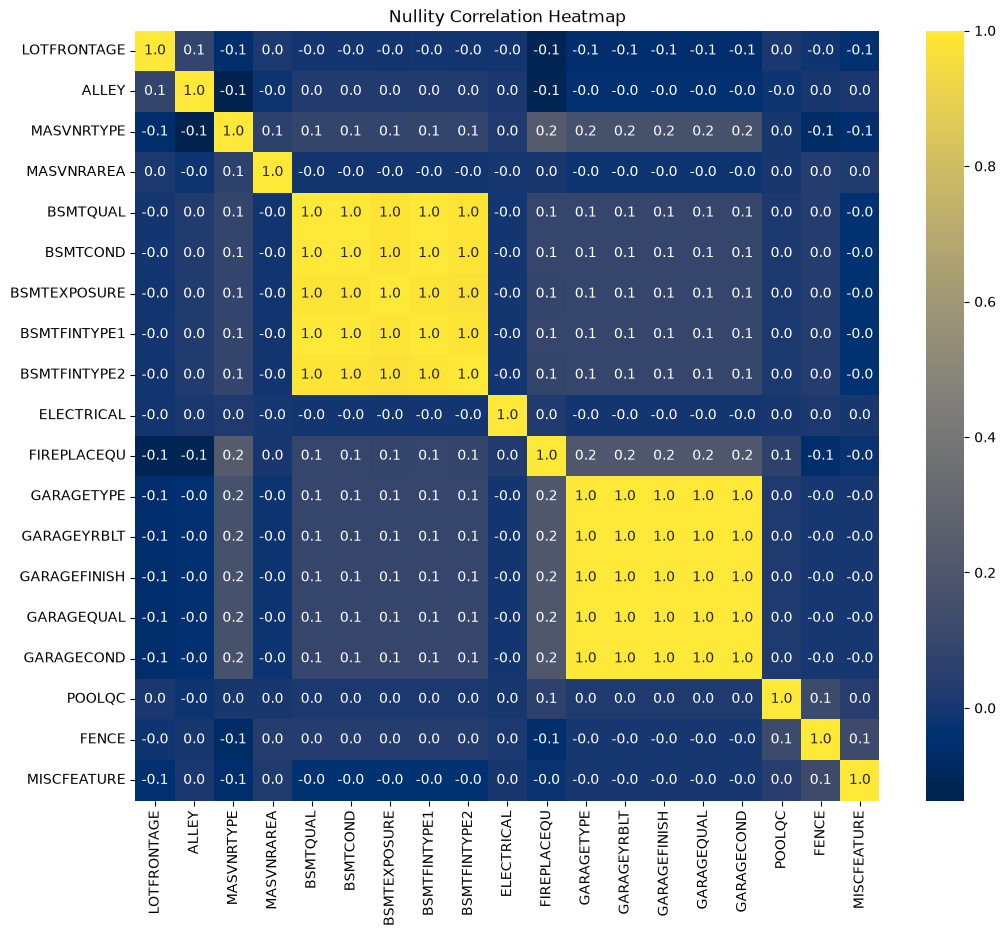

In [ ]:
# CHECK IF MISSINGNESS CLUSTERS

zero_null_values = nulls_per_column[nulls_per_column['SUM'] == 0].index
nullity_correlation = df.isnull().corr()
nullity_correlation = nullity_correlation.drop(index=zero_null_values, columns=zero_null_values)

plt.figure(figsize=(12,10))
ax = plt.axes()

sns.heatmap(nullity_correlation, annot=True, fmt='.1f', cmap='cividis', ax=ax)
ax.set_title('Nullity Correlation Heatmap')
plt.show()

**ANALYSIS**: The columns related to **garage**, like GARAGEQUAL, GARAGEFINISH, GARAGETYPE, GARAGEYRBLT, and GARAGECOND, have a strong relation of occurrence. The same phenomenon occurs in columns related to **basement**: BSMTFINTYPE2, BSMTEXPOSURE, BSMTCOND, BSMTQUAL, and BSMTFINTYPE1.

This phenomenon may indicate that an issue occurred in data collection. A fair conclusion is that these null values indicate that there are properties without a garage and basement that are classified with NULL VALUES.

In [188]:
## CHECK FOR "FAKE" NULLS DISGUISED AS STRINGS

columns_str = df.select_dtypes(include='string')
for col in columns_str.columns:
   print(df[col].value_counts(), '\n')


MSZONING
RL         1151
RM          218
FV           65
RH           16
C (ALL)      10
Name: count, dtype: int64 

STREET
PAVE    1454
GRVL       6
Name: count, dtype: int64 

ALLEY
GRVL    50
PAVE    41
Name: count, dtype: int64 

LOTSHAPE
REG    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 

LANDCONTOUR
LVL    1311
BNK      63
HLS      50
LOW      36
Name: count, dtype: int64 

UTILITIES
ALLPUB    1459
NOSEWA       1
Name: count, dtype: int64 

LOTCONFIG
INSIDE     1052
CORNER      263
CULDSAC      94
FR2          47
FR3           4
Name: count, dtype: int64 

LANDSLOPE
GTL    1382
MOD      65
SEV      13
Name: count, dtype: int64 

NEIGHBORHOOD
NAMES      225
COLLGCR    150
OLDTOWN    113
EDWARDS    100
SOMERST     86
GILBERT     79
NRIDGHT     77
SAWYER      74
NWAMES      73
SAWYERW     59
BRKSIDE     58
CRAWFOR     51
MITCHEL     49
NORIDGE     41
TIMBER      38
IDOTRR      37
CLEARCR     28
STONEBR     25
SWISU       25
MEADOWV     17
BLMNGTN     17
BRDALE   